<a href="https://colab.research.google.com/github/17Manu11/Pr-cticas/blob/main/EjAlgAvanzadosClasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1

In [ ]:
from sklearn.svm import SVC
import numpy as np

# Datos proporcionados en el enunciado
rng = np.random.default_rng(seed=5)
MatCov = np.array([[6, -3], [-3, 3.5]])
X_v1 = rng.multivariate_normal([0, 0], MatCov, size=150)
radios2 = X_v1[:, 0]**2 + X_v1[:, 1]**2
y_v1 = np.where(radios2 > 1.5, 1, -1)
pos_neg1 = np.logical_and(X_v1[:, 0] < 0, X_v1[:, 1] < 0)
pos_neg2 = np.logical_and(np.logical_and(X_v1[:, 0] > -2.5, X_v1[:, 0] < -1.5),
                          np.logical_and(X_v1[:, 1] < 2.5, X_v1[:, 1] > 1.25))
y_v1 = y_v1.copy()
y_v1[pos_neg1 == True] = -1
y_v1[pos_neg2 == True] = -1

# A) Entrenamiento de la SVM no lineal
# Usamos C=10 para ser estrictos y gamma=1 para capturar los recortes
svm_modelo = SVC(kernel='rbf', C=10.0, gamma=1)
svm_modelo.fit(X_v1, y_v1)

SVC(C=10.0, gamma=1)

**B) ¿Qué parámetros y valores ha usado? ¿por qué cree que esos parámetros han logrado un ajuste sin error?**

Valores usados: kernel='rbf', C=10, gamma=1

Kernel RBF: Permite crear fronteras curvas. Como el enunciado define las clases mediante una elipse y condiciones lógicas, una línea recta (kernel lineal) fallaría.

C=10: Al ser un valor alto, aumenta la importancia de clasificar correctamente cada punto de entrenamiento. Esto obliga al modelo a no permitir "fallos aceptables" en favor de un margen más ancho.

γ=1: Determina el alcance de la influencia de cada punto. Un valor de 1 es lo suficientemente alto para que el modelo pueda "dibujar" con detalle los recortes específicos sin que la frontera sea demasiado rígida.

In [ ]:
# C) Cálculo de la cantidad de errores de clasificación
y_pred = svm_modelo.predict(X_v1)
errores = np.sum(y_pred != y_v1)

print(f'Cantidad de muestras mal clasificadas: {errores} de {X_v1.shape[0]}')

Cantidad de muestras mal clasificadas: 0 de 150


# Ejercicio 2

In [ ]:
# A) Entrenamiento de árbol de decisión con Iris

# Cargar Iris
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
iris = datasets.load_iris()
X_completo = iris.data[:, [2, 3]]
y_completo = iris.target

# Dividir conjunto
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X_completo, y_completo, test_size=0.3,
    random_state=10, stratify=y_completo)

# Entrenamiento con entropía y mínima profundidad para 3 clases
# max_depth=2 es el mínimo para identificar las 3 etiquetas existentes
arbol = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=10)
arbol.fit(X_entrenamiento, y_entrenamiento)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=10)

**B) ¿Cuántas preguntas hay que hacer para clasificar una muestra?**

 En este modelo hay que hacer como máximo 2 preguntas.

 Esto sucede porque al definir max_depth=2, el árbol se limita a dos niveles de decisión. La primera pregunta separa una clase (Setosa) y la segunda divide el espacio restante para intentar separar las otras dos (Versicolor y Virginica). Con menos de 2 preguntas (profundidad 1) sería imposible distinguir las 3 clases existentes.

**C) ¿Qué modelo cree que está menos ajustado?**

El modelo menos ajustado es el que acabamos de implementar (profundidad 2).

En primer lugar, el árbol con profundidad 5 es un modelo mucho más complejo. Tiene mayor capacidad para “ajustarse” a las particularidades, ruidos y casos atípicos del conjunto de entrenamiento (overfitting).

En cambio, el modelo de profundidad 2 es más simple y rígido. Al obligarle a clasificar con tan pocas preguntas, le impedimos aprender los detalles minuciosos del entrenamiento, haciendo que se quede solo con las reglas más generales. Por ello, está menos ajustado a los datos de entrenamiento específicos que el de profundidad 5.

# Ejercicio 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.colors import ListedColormap

# Cogemos la función que se hizo en la práctica
def pintar_regiones_decision_v2(X, y, clasificador, test_idx=None, resolucion=0.02):
    # Configurar los marcadores y el mapa de color
    marcadores = ('s', 'x', 'o', '^', 'v')
    colores = ['red', 'blue', 'lightgreen', 'gray', 'cyan']
    # Asignación de colores a las clases
    cmap = ListedColormap(colores[:len(np.unique(y))])

    # Preparar los márgenes de la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Preparar los valores puntuales de la superficie de decisión y el valor del
    # clasifidor para dichos puntos
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolucion),
                           np.arange(x2_min, x2_max, resolucion))

    # Pasamos la entrada a matriz con dos columnas para calcular la salida del clasificador
    Z = clasificador.predict(np.array([xx1.reshape(-1), xx2.reshape(-1)]).T)
    # Convertimos la salida predicha al formato adecuado para pintar la superficie
    Z = Z.reshape(xx1.shape)

    # Pintar el contorno de la superficie de decisión y se rellena también
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Pintar todas las muestras en la superficie de decisión
    for idx, cl in enumerate(np.unique(y)):
         plt.scatter(x=X[y == cl, 0],
                     y=X[y == cl, 1],
                     alpha=0.8,
                     c=colores[idx],
                     marker=marcadores[idx],
                     label=cl,
                     edgecolor='black')

    # Marcar las que son muestras de test
    if test_idx:
        # Dibujar todas las muestras
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0], X_test[:, 1],
                    facecolors='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Conjunto de test')


# 1. Generación de los datos (Ejercicio 1)
rng = np.random.default_rng(seed=5)
MatCov = np.array([[6, -3], [-3, 3.5]])
X_v1 = rng.multivariate_normal([0, 0], MatCov, size=150)
radios2 = X_v1[:, 0]**2 + X_v1[:, 1]**2
y_v1 = np.where(radios2 > 1.5, 1, -1)

pos_neg1 = np.logical_and(X_v1[:, 0] < 0, X_v1[:, 1] < 0)
pos_neg2 = np.logical_and(np.logical_and(X_v1[:, 0] > -2.5, X_v1[:, 0] < -1.5),
                          np.logical_and(X_v1[:, 1] < 2.5, X_v1[:, 1] > 1.25))

y_v1 = y_v1.copy()
y_v1[pos_neg1 == True] = -1
y_v1[pos_neg2 == True] = -1

# División de datos y obtención de índices para la función de pintado
indices = np.arange(len(X_v1))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_v1, y_v1, indices, test_size=0.3, random_state=5
)

# A) Entrenamiento de los Árboles
arbol_A = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=5)
arbol_B = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=5)

arbol_A.fit(X_train, y_train)
arbol_B.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=6, random_state=5)

/tmp/ipython-input-252/1168265777.py:36: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


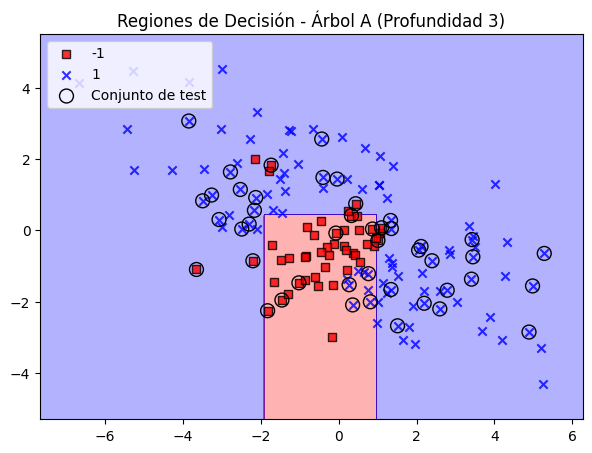

/tmp/ipython-input-252/1168265777.py:36: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


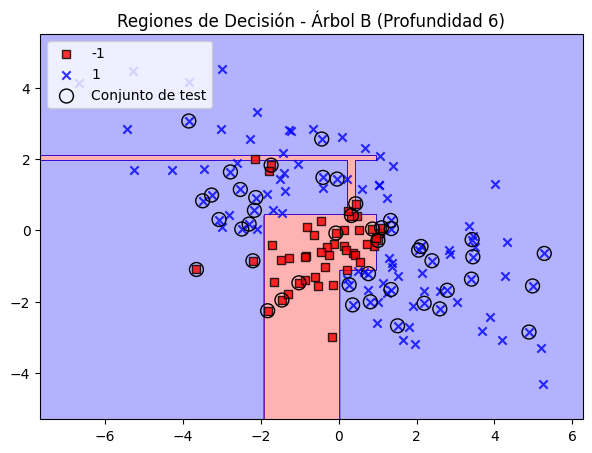

In [ ]:
# B) Gráficas de las Regiones de Decisión
# Dibujamos primero el Árbol A
plt.figure(figsize=(7, 5))
pintar_regiones_decision_v2(X_v1, y_v1, arbol_A, test_idx=idx_test.tolist())
plt.title("Regiones de Decisión - Árbol A (Profundidad 3)")
plt.legend(loc='upper left')
plt.show()

# Dibujamos luego el Árbol B
plt.figure(figsize=(7, 5))
pintar_regiones_decision_v2(X_v1, y_v1, arbol_B, test_idx=idx_test.tolist())
plt.title("Regiones de Decisión - Árbol B (Profundidad 6)")
plt.legend(loc='upper left')
plt.show()

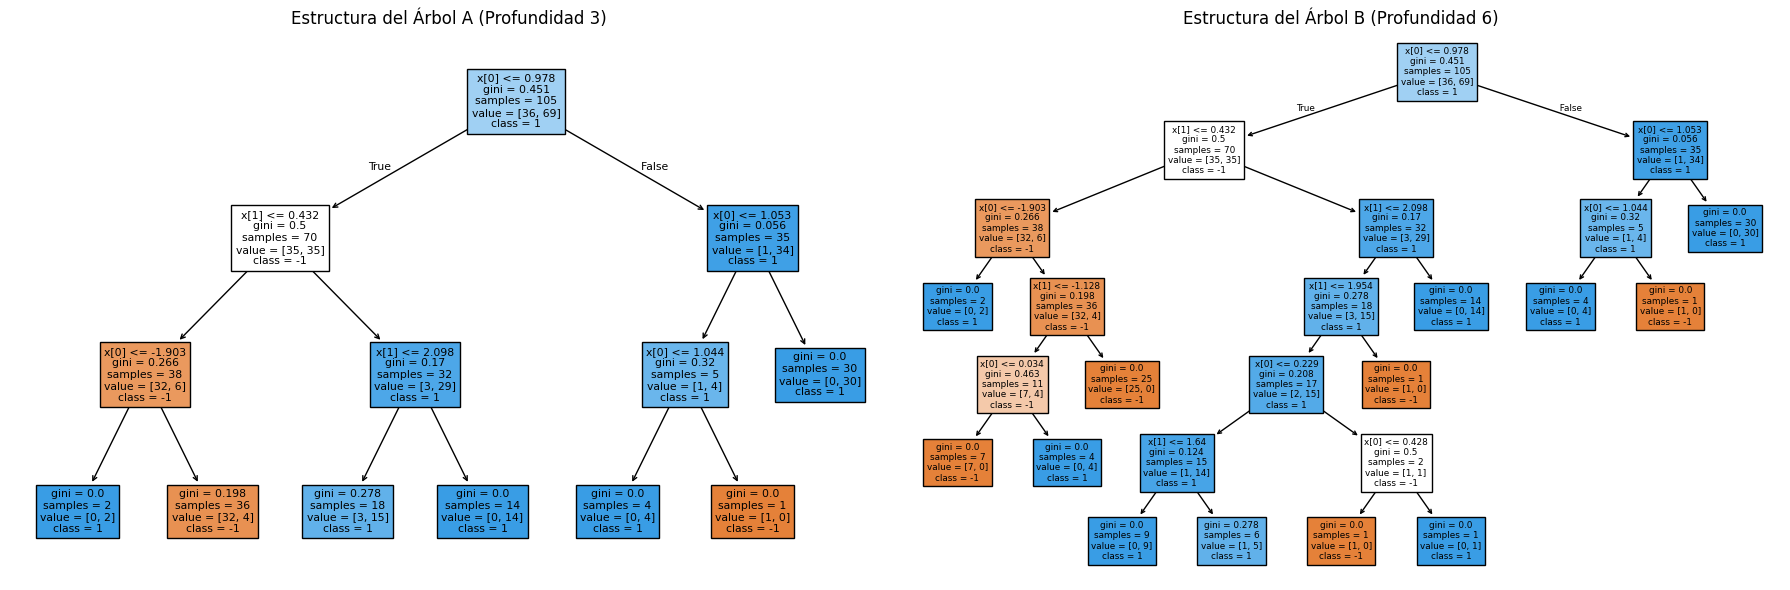

In [ ]:
from sklearn.tree import plot_tree

# C) Dibujar los árboles de preguntas
# Creamos una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Dibujamos el Árbol A
plot_tree(arbol_A, filled=True, ax=ax1, class_names=['-1', '1'])
ax1.set_title("Estructura del Árbol A (Profundidad 3)")

# Dibujamos el Árbol B
plot_tree(arbol_B, filled=True, ax=ax2, class_names=['-1', '1'])
ax2.set_title("Estructura del Árbol B (Profundidad 6)")

plt.tight_layout()
plt.show()

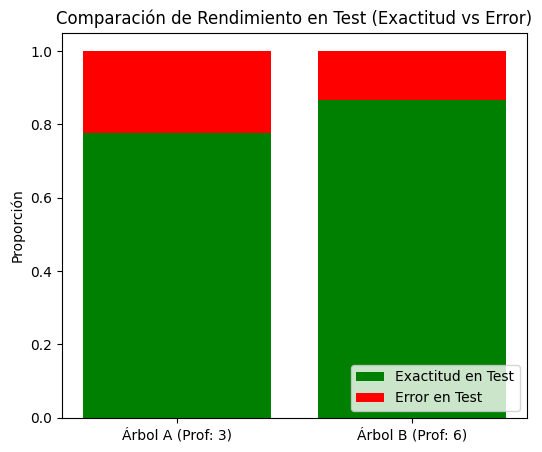

In [ ]:
# D) Gráfico de barras apiladas rendimiento en test

# Calculamos exactitud y error para ambos árboles usando los datos de TEST
exactitud_A = arbol_A.score(X_test, y_test)
error_A = 1 - exactitud_A

exactitud_B = arbol_B.score(X_test, y_test)
error_B = 1 - exactitud_B

# Preparamos las listas para el gráfico
etiquetas = ['Árbol A (Prof: 3)', 'Árbol B (Prof: 6)']
exactitudes = [exactitud_A, exactitud_B]
errores = [error_A, error_B]

# Dibujamos el gráfico
plt.figure(figsize=(6, 5))

# Barra verde (Exactitud)
plt.bar(etiquetas, exactitudes, color='green', label='Exactitud en Test')

# Barra roja apilada (Error) usando 'bottom=exactitudes' para que empiece donde acaba la verde
plt.bar(etiquetas, errores, bottom=exactitudes, color='red', label='Error en Test')

plt.ylabel('Proporción')
plt.title('Comparación de Rendimiento en Test (Exactitud vs Error)')

plt.legend(loc='lower right')
plt.show()

**E) Para saber qué modelo tiene mejor capacidad de generalización, ¿sería necesario conocer el rendimiento en el conjunto entrenamiento?**

No, no es necesario conocer el rendimiento en el conjunto de entrenamiento. La capacidad de generalización de un modelo se define exclusivamente por su habilidad para predecir correctamente datos nuevos que nunca ha visto. Por lo tanto, evaluar su rendimiento en el conjunto de test es el único indicador real y necesario para saber si generaliza bien.

**f) ¿Cuál de los dos árboles generaliza mejor? ¿por qué el otro árbol generaliza peor, diría que tiende al sobreajuste o al subajuste?**

El Árbol B (profundidad 6) generaliza mejor, ya que obtiene una mayor exactitud en el conjunto de test (aprox. 86.7%) en comparación con el Árbol A (aprox. 77.8%).

El otro árbol, el Árbol A (profundidad 3), generaliza peor porque tiende claramente al subajuste. La distribución de estos datos es altamente no lineal. Una profundidad máxima de 3 solo permite hacer 3 preguntas sucesivas (dividiendo el espacio en unos pocos bloques rectangulares grandes), lo que hace que el modelo sea demasiado simple y carezca de la flexibilidad necesaria para aproximarse a esas fronteras tan complejas.

Nota adicional: Aunque el Árbol B "gana" esta comparativa, es importante notar que, al observar sus regiones de decisión y su rendimiento en entrenamiento (cercano al 99%), el Árbol B está empezando a mostrar signos de sobreajuste, creando fronteras muy irregulares para capturar el ruido. Sin embargo, en este caso específico, el subajuste del Árbol A es tan severo que penaliza más el rendimiento que el sobreajuste incipiente del Árbol B.

# Ejercicio 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Generación de los datos (Enunciado)
np.random.seed(15)
X_v4 = np.random.randn(150, 2)

pos_Clase1 = np.logical_and(X_v4[:, 0] > 0, X_v4[:, 1] > 0)
pos_Clase2 = np.logical_and(X_v4[:, 0] < -0.5, X_v4[:, 1] < 0)

y_v4 = np.zeros(X_v4.shape[0])
y_v4[pos_Clase1] = 1
y_v4[pos_Clase2] = 2

# 2. División 70% Train / 30% Test
# Obtenemos también los índices para poder dibujarlos luego
indices = np.arange(len(X_v4))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_v4, y_v4, indices, test_size=0.3, random_state=10
)

# A) Entrenamiento de los modelos
# 1. Regresión Logística
modelo_rl = LogisticRegression(solver='lbfgs')
modelo_rl.fit(X_train, y_train)

# 2. Árbol de Decisión
modelo_arbol = DecisionTreeClassifier()
modelo_arbol.fit(X_train, y_train)

# 3. K-Nearest Neighbors (KNN)
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# B) Evaluación rendimiento
acc_rl = accuracy_score(y_test, modelo_rl.predict(X_test))
acc_arbol = accuracy_score(y_test, modelo_arbol.predict(X_test))
acc_knn = accuracy_score(y_test, modelo_knn.predict(X_test))

print(f"Exactitud Regresión Logística: {acc_rl * 100:.2f}%")
print(f"Exactitud Árbol de Decisión:   {acc_arbol * 100:.2f}%")
print(f"Exactitud KNN:                 {acc_knn * 100:.2f}%")

Exactitud Regresión Logística: 77.78%
Exactitud Árbol de Decisión:   100.00%
Exactitud KNN:                 97.78%


El peor modelo para clasificar estas muestras es la Regresión Logística. Utilizando la medida de exactitud (accuracy) sobre el conjunto de test, observaremos que la Regresión Logística obtiene el valor más bajo de los tres, mientras que el Árbol de Decisión y KNN se acercan al 100%.

**C) ¿Por qué el modelo no se adapta tan bien?**

La Regresión Logística es un clasificador lineal. Esto significa que solo puede separar las clases dibujando líneas rectas ininterrumpidas a lo largo de todo el espacio. Sin embargo, las reglas con las que se generaron los datos  crean fronteras con formas de "esquinas" o recortes perpendiculares. Una línea recta no puede doblarse en 90 grados para rodear un cuadrante, por lo que la Regresión Logística se ve obligada a trazar diagonales que inevitablemente cortan zonas incorrectas y clasifican mal muchos puntos.

Por el contrario, el Árbol de Decisión es perfecto para esto porque su naturaleza consiste precisamente en hacer cortes rectos perpendiculares a los ejes (es decir, puede modelar esquinas a la perfección).

/tmp/ipython-input-252/1168265777.py:36: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],
/tmp/ipython-input-252/1168265777.py:36: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


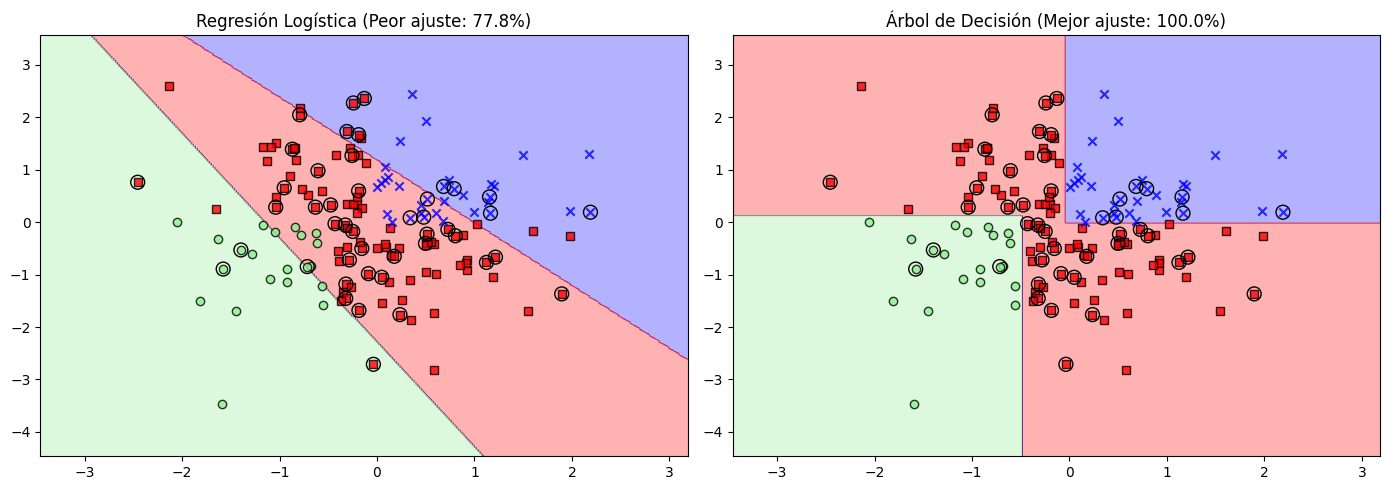

In [ ]:
# C) Gráficas para justificar la respuesta

fig = plt.figure(figsize=(14, 5))

# Gráfica 1: El peor modelo (Regresión Logística)
plt.subplot(1, 2, 1)
pintar_regiones_decision_v2(X_v4, y_v4, modelo_rl, test_idx=idx_test.tolist())
plt.title(f"Regresión Logística (Peor ajuste: {acc_rl*100:.1f}%)")

# Gráfica 2: El modelo ideal (Árbol de Decisión)
plt.subplot(1, 2, 2)
pintar_regiones_decision_v2(X_v4, y_v4, modelo_arbol, test_idx=idx_test.tolist())
plt.title(f"Árbol de Decisión (Mejor ajuste: {acc_arbol*100:.1f}%)")

plt.tight_layout()
plt.show()

# Ejercicio 5

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# PREPARACIÓN DE LOS DATOS
# Definimos los nombres de las columnas que indica el enunciado
nombres_columnas = ['Acidez', 'Acidez volátil', 'Ácido cítrico',
                    'Azúcar', 'Cloruros', 'DS libre',
                    'DS total', 'Densidad', 'pH',
                    'Sulfitos', 'Alcohol', 'Calidad']

# Cargamos el csv
df = pd.read_csv('winequality-red.csv', header=0, names=nombres_columnas)

# Separamos características (X) y clase deseada (y)
X = df.drop('Calidad', axis=1).values
y = df['Calidad'].values

# Dividimos 70% Train y 30% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=10)

# Escalamos las muestras
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


# A) Información de las clases
calidades_unicas = np.unique(y)
print(f"Hay {len(calidades_unicas)} calidades distintas de vinos.")
print(f"   La calidad mínima es {y.min()} y la máxima es {y.max()}.\n")

Hay 6 calidades distintas de vinos.
   La calidad mínima es 3 y la máxima es 8.



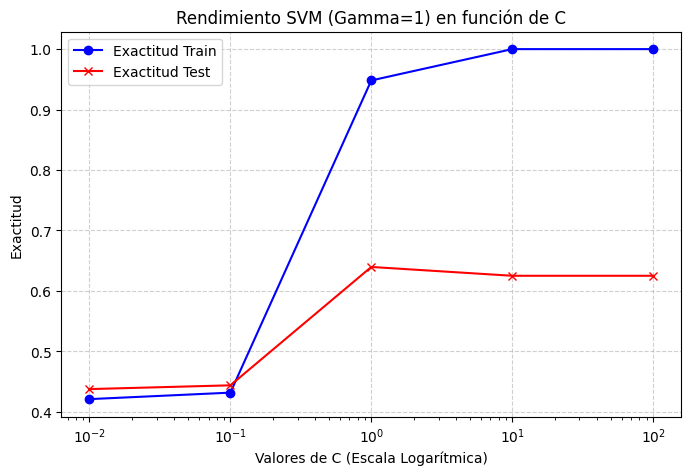

In [ ]:
# B) SVM no lineal

valores_C = [10**-2, 10**-1, 1, 10, 10**2]
exactitud_train = []
exactitud_test = []

for c in valores_C:
    # Entrenamos SVM con RBF (no lineal), gamma=1 y la C correspondiente
    modelo_svm = SVC(kernel='rbf', gamma=1, C=c)
    modelo_svm.fit(X_train_std, y_train)

    # Guardamos exactitudes
    exactitud_train.append(accuracy_score(y_train,
                                      modelo_svm.predict(X_train_std)))
    exactitud_test.append(accuracy_score(y_test,
                                      modelo_svm.predict(X_test_std)))

# Gráfica del apartado b
plt.figure(figsize=(8, 5))
# Usamos escala logarítmica en X porque las C crecen en potencias de 10
plt.plot(valores_C, exactitud_train, marker='o',
         color='blue', label='Exactitud Train')
plt.plot(valores_C, exactitud_test, marker='x',
         color='red', label='Exactitud Test')
plt.xscale('log')
plt.xlabel('Valores de C')
plt.ylabel('Exactitud')
plt.title('Rendimiento SVM (Gamma=1) en función de C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

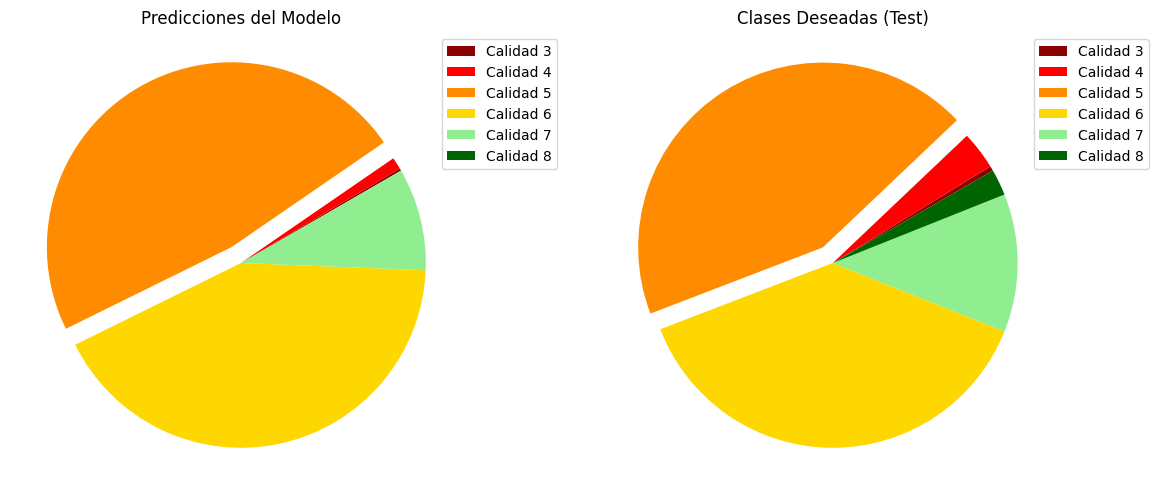

In [ ]:
# C) Diagramas de sectores

# Entrenamos el modelo
modelo_final = SVC(kernel='rbf', gamma=1, C=100)
modelo_final.fit(X_train_std, y_train)

# Predicciones sobre el conjunto de test
y_pred = modelo_final.predict(X_test_std)

etiquetas = ['Calidad 3', 'Calidad 4', 'Calidad 5',
             'Calidad 6', 'Calidad 7', 'Calidad 8']
colores = ['darkred', 'red', 'darkorange', 'gold',
           'lightgreen', 'darkgreen']

# Tamaños calculados
tamaños_pred = [np.sum((y_pred == 3)), np.sum((y_pred == 4)),
                np.sum((y_pred == 5)), np.sum((y_pred == 6)),
                np.sum((y_pred == 7)), np.sum((y_pred == 8))]

tamaños_real = [np.sum((y_test == 3)), np.sum((y_test == 4)),
                np.sum((y_test == 5)), np.sum((y_test == 6)),
                np.sum((y_test == 7)), np.sum((y_test == 8))]

# Para cortar el sector más numeroso
explode_pred = [0.1 if i == np.argmax(tamaños_pred) else 0
                for i in range(len(tamaños_pred))]
explode_real = [0.1 if i == np.argmax(tamaños_real) else 0
                for i in range(len(tamaños_real))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Primer diagrama: Predicciones
ax1.pie(tamaños_pred, explode=explode_pred, labels=etiquetas,
        colors=colores, startangle=30, labeldistance=None)
ax1.set_title("Predicciones del Modelo")
ax1.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# Segundo diagrama: Clases Reales
ax2.pie(tamaños_real, explode=explode_real, labels=etiquetas,
        colors=colores, startangle=30, labeldistance=None)
ax2.set_title("Clases Deseadas (Test)")
ax2.legend(loc='upper right', bbox_to_anchor=(1.2, 1)) # Leyenda obligatoria

plt.show()

**D) ¿Clasifica bien las muestras? Comente los resultados que observa en los diagramas del apartado anterior.**

No, el modelo no clasifica bien las muestras.
Al comparar los dos diagramas de sectores, se observa claramente que el modelo es incapaz de predecir la verdadera variedad de los datos. Mientras que en el conjunto de test real (diagrama de la derecha) existen muestras de todas las calidades (del 3 al 8), en las predicciones del modelo (diagrama de la izquierda) las calidades extremas como la 3 y la 8 desaparecen por completo, y la calidad 4 se reduce de forma drástica.

Esto ocurre porque la máquina de vectores de soporte, al estar configurada con parámetros tan extremos (C=102 y γ=1), sufre de un grave sobreajuste. El modelo ha memorizado el conjunto de entrenamiento creando fronteras de decisión demasiado cerradas y específicas. Como consecuencia, pierde totalmente la capacidad de generalizar ante datos nuevos y opta por asignar casi todas las muestras de test a las clases mayoritarias (calidades 5 y 6), ignorando los matices de los vinos restantes.